In [ ]:
# Dimensionality reduction analysis

After applying the different clustering algorithms, we now look at ways to improve the obtained results. One way to do so is by applying dimension reduction techniques such as Principal Component Analysis (PCA) and Canonical Correlation Analysis (CCA).


**<font color='red'>PCA:</font>** This method is used to reduced the dimensions of the data. In fact, sometimes we have variables that do not give any information about the data and thus removing these variables can lead to better results.  

**<font color='red'>CCA:</font>** This method is used to detect correlations between different subgroups of data. In fact, sometimes we have variables that are so strongly correlated that reducing the dimensions using linear combinations between the correlated variables can imporove the results
It is **important to note that we will NOT use the labels when applying PCA and CCA.**

___


Therefore, in this part of the project, you will apply both PCA and CCA on the data you chose in the clustering part. Afterwards, you will apply the clustering method that gave the best results in TD2_3 on the reduced dataset you obtained from the PCA step.

**You should send this notebook filled with your results before 11.59pm on Sunday 8 December.**

You must submit it using eCampus, or send a mail to either massinissa.hamidi@univ-evry.fr or clement.bernard@univ-evry.fr.

## Mount Drive

**For google colab users only**

In [1]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# Change to the directory to where your files are
os.chdir('drive/My Drive/Colab Notebooks')

Mounted at /content/drive


## Import Libraries

**Tip**: look at the documentation of the packages and methods imported, they can help you answer some questions.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

## Load the dataset, separate data from classes



Load the dataset you are using in your project and separate the data from the class.

**<font color='red'>N.B:</font>** If you have applied some preprocessing steps (missing value replacement, factorize), please used the dataset you obtained after all the steps (you should have saved your dataset in notebook TD2_3.ipynb) without the normalization step.





In [3]:
df = pd.read_csv("train.csv")

In [4]:
label_df = df["price_range"]
variables_df = df.drop("price_range", axis=1)

## Part 1: Apply PCA


##### We start by scaling the data so that each feature has a single unit variance.  


**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale both continuous and numerical variables.
PCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_variables = scaler.fit_transform(variables_df)
scaled_variables_df = pd.DataFrame(scaled_variables, columns=variables_df.columns)
scaled_variables_df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099



##### We then instantiate a PCA object.

The main parameter of this method is the max number of components. In this project, we will choose it to be equal to the max number of variables in the data.


In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=scaled_variables_df.shape[1])
pca.fit(scaled_variables_df)
data_pca = pca.transform(scaled_variables_df)
data_pca.shape

(2000, 20)

### Interpreting the components

The next step is to choose the number of components to keep.

##### Plot the explained variance of each component using the corrected variance.

In [7]:
print("Explained variance")
print(pca.explained_variance_)

number_samples = data_pca.shape[0]
corrected_variance = (number_samples / (number_samples - 1)) * pca.explained_variance_
print("\nCorrected variance")
print(corrected_variance)

Explained variance
[1.67809669 1.62330659 1.58336253 1.42975987 1.12207212 1.08768022
 1.06617731 1.02092877 1.0175506  1.00618845 0.9812144  0.97531969
 0.95271479 0.95212529 0.89928323 0.87655734 0.50105488 0.47253596
 0.41304483 0.35103144]

Corrected variance
[1.67893616 1.62411865 1.58415461 1.43047511 1.12263344 1.08822434
 1.06671066 1.02143948 1.01805963 1.00669179 0.98170526 0.97580759
 0.95319139 0.9526016  0.89973309 0.87699584 0.50130553 0.47277234
 0.41325146 0.35120704]


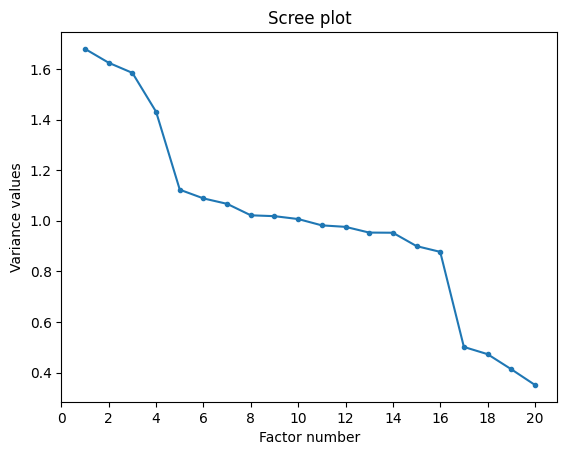

In [8]:
number_components = data_pca.shape[1]
plt.plot(np.arange(1, number_components + 1), corrected_variance, marker='.')
plt.xticks(np.arange(0, number_components + 1, 2)) # Force integers on X axis
plt.title("Scree plot")
plt.ylabel("Variance values")
plt.xlabel("Factor number")
plt.show()

##### Plot the cumulative variance of the components based on the explained variance ratio.

In [9]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_*100)
print(cumulative_variance)

[  8.38628821  16.49876289  24.41161715  31.55684209  37.16439752
  42.60007944  47.92830053  53.03039204  58.11560117  63.14402793
  68.04764692  72.92180707  77.68299924  82.4412454   86.93541332
  91.31600865  93.8200304   96.18152884  98.24572039 100.        ]


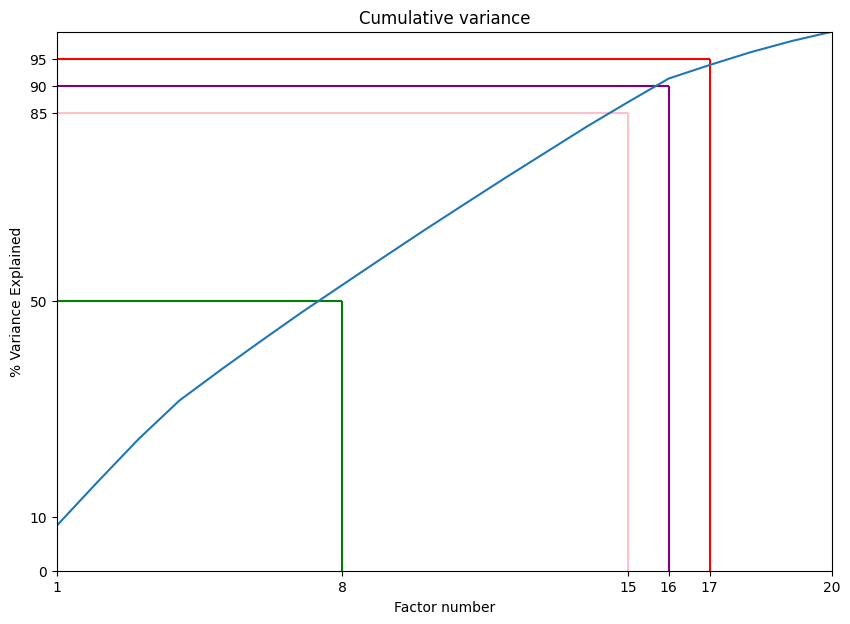

In [10]:
plt.figure(figsize=(10,7))
plt.title("Cumulative variance")
plt.ylabel('% Variance Explained')
plt.xlabel('Factor number')

plt.hlines(y=95.0, xmin=0, xmax=17, color='red')
plt.vlines(x=17, ymin=0, ymax=95,color='red')

plt.hlines(y=90.0,xmin=0, xmax=16, color='purple')
plt.vlines(x=16, ymin=0, ymax=90, color='purple')

plt.hlines(y=50.0, xmin=0, xmax=8, color='green')
plt.vlines(x=8, ymin=0, ymax=50, color='green')

plt.hlines(y=85.0, xmin=0, xmax=15, color='pink')
plt.vlines(x=15, ymin=0, ymax=85, color='pink')

plt.ylim(0,100)
plt.xlim(1,20)
plt.yticks([0,10,50,85,90,95])
plt.xticks([1,8,15,16,17,20])
plt.style.context('seaborn-whitegrid')
plt.plot(np.arange(1, number_components + 1), cumulative_variance)
plt.show()

##### How many components will you keep? Explain your choice.

**The plot is mostly linear and there is no apparent flattening curve around the higher percentages that would otherwise help pick a well-balanced number, but it still gets sligtly less steep at around 16 components, which explain a little over 90% of the variance. This means that each component after that carries very slightly less information.**

**While the difference is marginal, we will continue with 16 components.**

**Note:** If you do choose to keep all components in your analysis, you do not perform any dimension reduction.

##### Create your reduced dimensionality dataset by only keeping the components you chose to keep in the above question.

In [11]:
data_pca_reduced = data_pca[:, :16]
data_pca_reduced.shape

(2000, 16)

##### What is the inertia percentage explained by the components you kept *(le pourcentage d’inertie expliquée par le premier axe factoriel)*?

What does it mean?

**The inertia percentage explained by a number x of principal components (factorial axes) corresponds to the percentage of the variance that is explained by these components.**

In [12]:
print(f"Variance explained by the first 16 components: {cumulative_variance[15]:.3f}%")
print(f"Variance explained by the first component alone: {cumulative_variance[0]:.3f}%")

Variance explained by the first 16 components: 91.316%
Variance explained by the first component alone: 8.386%


##### Calculate the contribution of the first individual to the first component *(la contribution du premier individu au premier axe factoriel)*.

In [13]:
coord_1st_indiv_1st_comp = data_pca[0, 0]
variance_1st_comp = corrected_variance[0]

# Contribution of an individual i to a principal component k: (coord_ik^2 / (n * variance_k)) * 100
ctr_1st_indiv_1st_comp = (coord_1st_indiv_1st_comp**2 / (number_samples * variance_1st_comp)) * 100

print(f"Contribution of the first individual to the first component: {ctr_1st_indiv_1st_comp:.5f}%")

Contribution of the first individual to the first component: 0.00312%


##### Calculate the quality of representation of this individual in the map made of the first factorial axis *(la qualité de représentation de cet individu dans le plan constitué du premier axe factoriel)*.

What can you deduce?

In [14]:
total_squared_dist_1st_indiv = np.sum(data_pca[0, :]**2)

# Quality of representation of individual i on principal component k: (coord_ik^2 / (total_squared_distance_i)) * 100
rep_quality_1st_indiv_1st_comp = (coord_1st_indiv_1st_comp**2 / total_squared_dist_1st_indiv) * 100

print(f"Quality of representation of the first individual: {rep_quality_1st_indiv_1st_comp:.5f}%")

Quality of representation of the first individual: 0.44678%


**The percentage we obtained is very low, which indicates that the first individual is poorly represented by the first principal component (factorial axis).**

**This means that the first principal component doesn't effectively capture the characteristics of the first individual, whose variability could potentially be better explained by other principal components, or a combination of them**

### Variable representation

#### Compute the correlation between the principal components and the variables

##### Print the correlation matrix.

In [15]:
sqrt_cor_var = np.sqrt(corrected_variance)
corvar = np.zeros((number_components, number_components))
for k in range(number_components):
  corvar[:,k] = pca.components_[k,:] * sqrt_cor_var[k]

# Convert to DataFrame for better readability
component_names = [f"PC{i+1}" for i in range(number_components)]
corvar_df = pd.DataFrame(corvar, index=scaled_variables_df.columns, columns=component_names)

display(corvar_df)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
battery_power,0.098572,0.041096,-0.025460,-0.097205,-0.425094,0.292804,-0.204046,0.060070,-0.123372,0.376814,0.006145,0.272436,0.194882,0.487453,-0.220931,0.333706,0.004976,-0.023404,0.003790,0.000702
blue,0.011970,-0.043855,-0.043307,0.084202,0.018899,0.486790,0.481909,0.137590,0.151716,-0.025808,0.280122,0.046884,-0.367681,0.338978,-0.080799,-0.371341,0.021959,-0.031196,0.031906,0.011728
clock_speed,0.060802,-0.123665,0.004598,0.035086,-0.008974,0.083322,0.166046,0.788478,-0.050096,0.128153,-0.247909,-0.085882,0.311391,-0.032483,0.366187,-0.063121,-0.024116,-0.003925,0.001951,0.001111
dual_sim,-0.039062,-0.051026,-0.033382,0.001663,0.581784,0.125734,0.073016,0.020371,0.283044,0.102700,0.204706,0.505604,-0.020109,-0.083353,0.237142,0.427062,-0.015589,0.033192,0.012858,-0.006616
fc,0.746252,0.470651,0.180666,0.041306,0.049082,-0.005404,0.041062,0.025345,-0.046559,-0.047303,0.001898,0.003427,-0.042679,-0.005466,0.010967,0.013219,0.030777,0.064639,0.042607,-0.412281
four_g,-0.318081,0.654694,-0.434725,-0.248006,-0.022452,0.053524,0.056390,0.039215,0.016734,-0.004676,-0.012889,0.004815,-0.021760,-0.003194,0.075057,-0.013472,-0.034032,-0.011259,-0.449803,-0.047154
int_memory,-0.095428,-0.015695,0.016280,0.081420,0.049499,0.556663,-0.087664,0.039452,-0.418061,-0.266012,0.081045,-0.397530,-0.195077,-0.162976,0.074145,0.426629,0.028563,0.003388,0.009042,0.004072
m_dep,0.051551,-0.013693,0.034636,-0.122916,-0.338386,0.184167,-0.159911,-0.048944,0.302244,-0.294337,0.586415,-0.037783,0.462425,-0.143906,0.196978,-0.091457,-0.005165,-0.001275,0.010117,-0.017914
mobile_wt,0.092008,-0.015016,-0.011065,-0.076883,-0.057290,-0.131725,-0.279230,0.259000,0.606066,0.233775,0.092732,-0.457711,-0.354932,0.035107,-0.083889,0.214294,-0.010117,-0.010157,-0.012315,0.001174
n_cores,-0.015164,-0.042457,0.061030,0.044897,-0.114757,-0.131277,0.622565,-0.308467,0.225278,-0.132923,-0.187056,-0.296510,0.231792,0.295857,0.145058,0.352647,-0.040834,0.014519,-0.011456,-0.009368


##### Plot the correlation circle

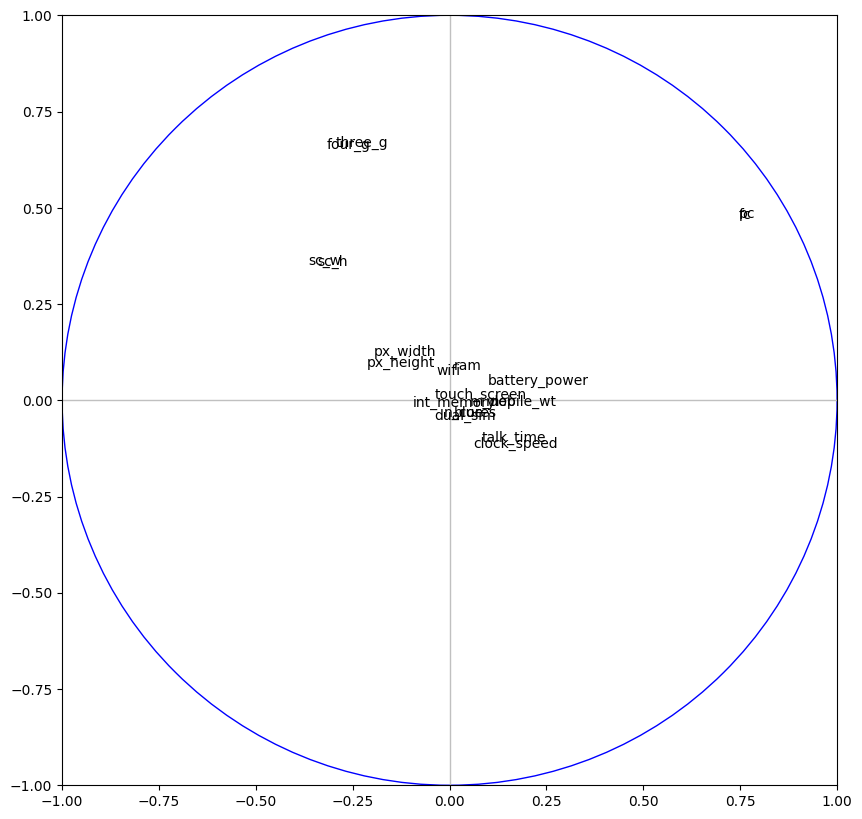

In [16]:
fig, axes = plt.subplots(figsize=(10,10))
axes.set_xlim(-1,1)
axes.set_ylim(-1,1)
for j in range(number_components):
     plt.annotate(scaled_variables_df.columns[j],(corvar[j,0],corvar[j,1]))

plt.plot([-1,1],[0,0],color='silver',linestyle='-',linewidth=1)
plt.plot([0,0],[-1,1],color='silver',linestyle='-',linewidth=1)

circle = plt.Circle((0,0),1,color='blue',fill=False)
axes.add_artist(circle)

plt.show()

##### Interpret the obtained results

**This circle represents the correlation between the original variables and the first 2 principal components, with PC1 as the x axis and PC2 as the y axis. Variables located near the edge of the circle are well represented by the plane formed by PC1 and PC2, while those located closer to the origin are poorly represented. The position of a variable in relation to the x axis indicates its correlation with PC1, while its position in relation to the y axis indicates its correlation with PC2.**

**We observe that the majority of the variables are clustered near the origin (0,0), which indicates that they are poorly represented on this specific plane. However, a few variables stand out: `three_g` and `four_g` are strongly correlated and projected positively on the vertical axis (y = ~0.7), meaning PC2 is more likely to represent aspects related to network capabilities.**

**`pc` (primary camera megapixels) and `fc` (front camera megapixels) are also well represented on the horizontal axis (x = ~0.75), meaning PC1 is more likely to better capture variance related to camera capabilities. They are also moderately related to PC2 (y = ~0.5).**

**`sc_w` (screen width) and `sc_h` (screen height) are also correlated, and moderately related to both PC1 and PC2 (x, y = ~0.3). Same goes for `px_width` and `px_height` (pixel resolution width and height), that are close to each other, though only slightly related to both PC1 and PC2.**

**This means that while neither PC1 nor PC2 alone can fully encapsulate the variance of the variables related to screen size, they offer a reasonable representation once considered together.**

**However, since most variables (`touch_screen`, `dual_sim`, `int_memory`, etc) still remain close to the center, the cumulative explained variance of these two principal components remains low. To find more correlations, we would need to analyze the correlation circles of other principal component combinations (like PC1-PC3 or PC3-PC4, and so on).**

## Applying clustering on the newly created dataset.

Recall in TD2_3.ipynb, you applied different clustering algorithms on your dataset and analyzed which method gave the best results on your dataset.

##### Apply this clustering method to the dataset you obtained after applying PCA and performing dimension reduction.

**Previously, we had determined that hierarchical clustering with 3 centers and complete linkage was likely the "least worst" clustering method among the ones we tried.**

In [17]:
from sklearn.cluster import AgglomerativeClustering

hclust_3 = AgglomerativeClustering(n_clusters=3, linkage="complete")
hclust_3_labels = hclust_3.fit_predict(data_pca_reduced)

##### Using the same metrics you used in TD2_3.ipynb, compare the results obtained with this method to the real classes.

In [18]:
from sklearn.metrics import rand_score, adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score

rand = rand_score(label_df, hclust_3_labels)
print("Rand index:", rand)

Rand index: 0.5629189594797399


In [19]:
adjusted_rand = adjusted_rand_score(label_df, hclust_3_labels)
print("Adjusted rand index:", adjusted_rand)

Adjusted rand index: 0.0005224432743988989


In [20]:
homogenity = homogeneity_score(label_df, hclust_3_labels)
print("Homogeneity score:", homogenity)

Homogeneity score: 0.0014755868807797465


In [21]:
completeness = completeness_score(label_df, hclust_3_labels)
print("Completeness score:", completeness)

Completeness score: 0.0019740223557320417


In [22]:
v_measure = v_measure_score(label_df, hclust_3_labels)
print("V-measure score:", v_measure)

V-measure score: 0.0016887950435972093


##### In your opinion, did dimensionality reduction help you in getting better results or not?

* **`Rand index:` 0.53 -> 0.56, very slightly higher but marginally identical.**
* **`Adjusted rand index:` 0.015 -> 0.0005, much worse after dimensionality reduction, although it is extremely low in both cases.**
* **`Homogenity:` 0.021 -> 0.0015, also lower after reduction, both very low.**
* **`Completeness:` 0.0306 -> 0.00197, also lower after reduction, both very low.**
* **`V-measure score:` 0.0305 -> 0.00169, also lower, both very low.**

**In conclusion, while the results we obtained with the original dataset were already very poor, applying PCA and dimensionality reduction doesn't seem to have improved the quality of the clustering at all; in fact, it has made it even worse.**

**This means that even though we retained over 90% of the cumulative variance by reducing the dimensions to 16 components, the specific variance captured by these components was not relevant in helping distinguish between the `price_range` categories.**

## Part 2: Apply CCA

Next steps:
   - Apply CCA /!\ Don't forget to split the dataset into two groups,i.e., p=3 and q=3
   - Analyze the correlation circle *(graphe des variables)*
   - Analyze the observation graph *(graphe des individus)*

**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale use continuous and numerical variables.
CCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

### Choice of the two groups

##### Show the correlation matrix of the data

In [23]:
corr = scaled_variables_df.corr()
corr.style.background_gradient(cmap='coolwarm')

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,0.031441,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,-0.009952,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,-0.005245,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,-0.017143,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,0.644595,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,-0.005598,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,-0.033273,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,0.026282,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,0.018844,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,-0.001193,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964


##### Split your data into two groups p and q

In [25]:
p_ext = scaled_variables_df[["px_height", "px_width", "sc_h", "sc_w", "m_dep", "mobile_wt", "touch_screen", "dual_sim"]]
q_int = scaled_variables_df[["pc", "fc", "three_g", "four_g", "wifi", "blue", "n_cores", "clock_speed", "ram", "int_memory", "battery_power", "talk_time"]]

##### How did you choose your two groups?

**There are only 4 groups of 2 variables that show any sign of correlation based on the correlation matrix:**
* **`pc` and `fc` (primary and front camera megapixels)**
* **`three_g` and `four_g`**
* **`px_height` and `px_width` (pixel resolution height and width)**
* **`sc_h` and `sc_w` (screen height and width)**

**So to construct our 2 groups, it is best to start with 2 of those pairs in each. Since pixel resolution and screen size are characteristics that are intuitively related, we add them to the group p, and so the remaining 2 pairs are added to group q.**

**A this point, the correlation matrix is no longer helpful since all the other possible pairs of variables have correlation values that are extremely close to 0, with no more noticeable pair that stands out. Instead, we will distribute the remaining 12 variables evenly across the 2 groups based on their intuitive (possibly loose) similarity with the ones that are already added and that define the pre-existing groups.**

**So far, group p represents characteristics related to screen size. Based on this, we can add other dimension-related variables like `m_dep` (depth), `mobile_wt` (weight). We can extend this notion to generally include external characteristics of the phone, like `touch_screen` and `dual_sim`.**

**Likewise, for group q, we have a pair of variables related to connectivity (3G/4G), and another for camera quality, which we can extend to generally include internal specifications of the phone. Based on this, we can add `wifi`, `blue` (bluetooth), `n_cores`, `clock_speed`, `ram`, `int_memory` (storage), `battery_power` and `talk_time` (time it takes to use up all the battery).**

### Apply CCA

CCA with scikit-learn uses a very similar process to other preprocessing functions that come with scikit-learn. We instantiate a CCA object, find the  components (linear combinations of the variables) using the fit method, then apply the dimensionality reduction by calling transform().

We can also specify how many components we want to keep when creating the CCA object.

Check the scikit-learn documentation for CCA. Do you need to use the scaled or unscaled data to apply CCA?



**We need to scale the data before applying CCA. The implementation from scikit-learn has a `scale` parameter to do it directly when creating the CCA object, however since we have already manually scaled our data in an earlier step, we will use the scaled data and set this parameter to false.**

##### Apply CCA

In [26]:
from sklearn.cross_decomposition import CCA

cca = CCA(n_components=2, scale=False)
cca.fit(p_ext, q_int)

p_scores, q_scores = cca.transform(p_ext, q_int)

##### Print the first two components

In [27]:
data_cca = pd.DataFrame({"p1": p_scores[:,0], "p2": p_scores[:,1], "q1": q_scores[:,0], "q2": q_scores[:,1]})
data_cca.head()

,p1,p2,q1,q2
0,-1.222559,0.319283,0.584881,-0.027873
1,0.392947,0.127524,1.066223,-0.985713
2,-0.064387,-0.652956,1.261697,0.091082
3,-0.506368,-0.247526,0.379478,0.953103
4,-1.288458,-0.517647,-1.600809,-0.942332


##### Print the correlation matrix between the first two components

In [28]:
corr_cca = data_cca.corr()
corr_cca.style.background_gradient(cmap='coolwarm')

,p1,p2,q1,q2
p1,1.000000,0.000000,0.114097,-0.000000
p2,0.000000,1.000000,-0.000006,0.092373
q1,0.114097,-0.000006,1.000000,-0.000000
q2,-0.000000,0.092373,-0.000000,1.000000


##### What can you conclude?

**p1 and q1 have the strongest correlation, followed by q1 and q2. This is expected from intra-group variables with the same index, while those with different indices, as well as inter-group ones, show no correlation.**

**However, even the p1-q1 and p2-q2 correlations are very low, indicating that the 2 groups we have chosen don't have a strong relationship with each other. This conclusion extends to the other components not shown in this matrix, since the correlation between p1 and q1 is already the highest that CCA can find between any linear combination of variables from p and q.**

### Results visualization and interpretation

#### Variable representation

##### Compute the correlation between the components and the variables

[*aide: utiliser les matrices centrées-réduites*]

In [32]:
cc_var = pd.concat((data_cca, scaled_variables_df), axis=1)

corr_cc_var = cc_var.corr(method='pearson')
corr_cc_var.style.background_gradient(cmap='coolwarm')

,p1,p2,q1,q2,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
p1,1.000000,0.000000,0.114097,-0.000000,-0.053533,0.025034,-0.008156,0.720597,-0.031957,0.022524,0.004671,-0.364436,-0.158003,-0.004894,-0.036847,0.147888,0.071308,0.049752,0.399523,0.542682,-0.050738,0.004467,-0.033764,0.053372
p2,0.000000,1.000000,-0.000006,0.092373,-0.021930,-0.032423,0.018231,-0.251437,0.003938,0.037316,-0.025392,-0.242937,0.027724,0.052032,-0.000420,-0.351316,0.371922,0.013043,-0.007048,0.396249,0.018373,0.048307,0.350901,0.000765
q1,0.114097,-0.000006,1.000000,-0.000000,-0.469188,0.219407,-0.071480,0.082218,-0.280083,0.197410,0.040937,-0.041572,-0.018036,-0.042892,-0.322947,0.016870,0.008137,0.436050,0.045598,0.061919,-0.444688,0.039154,-0.003862,0.467772
q2,-0.000000,0.092373,-0.000000,1.000000,-0.237436,-0.350986,0.197362,-0.023238,0.042611,0.403985,-0.274881,-0.022417,0.002531,0.563272,-0.004571,-0.032456,0.034373,0.141222,-0.000603,0.036617,0.198875,0.522956,0.032391,0.008306
battery_power,-0.053533,-0.021930,-0.469188,-0.237436,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,0.031441,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343
blue,0.025034,-0.032423,0.219407,-0.350986,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,-0.009952,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863
clock_speed,-0.008156,0.018231,-0.071480,0.197362,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,-0.005245,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471
dual_sim,0.720597,-0.251437,0.082218,-0.023238,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,-0.017143,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740
fc,-0.031957,0.003938,-0.280083,0.042611,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,0.644595,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085
four_g,0.022524,0.037316,0.197410,0.403985,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,-0.005598,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620


##### Show the correlation circle

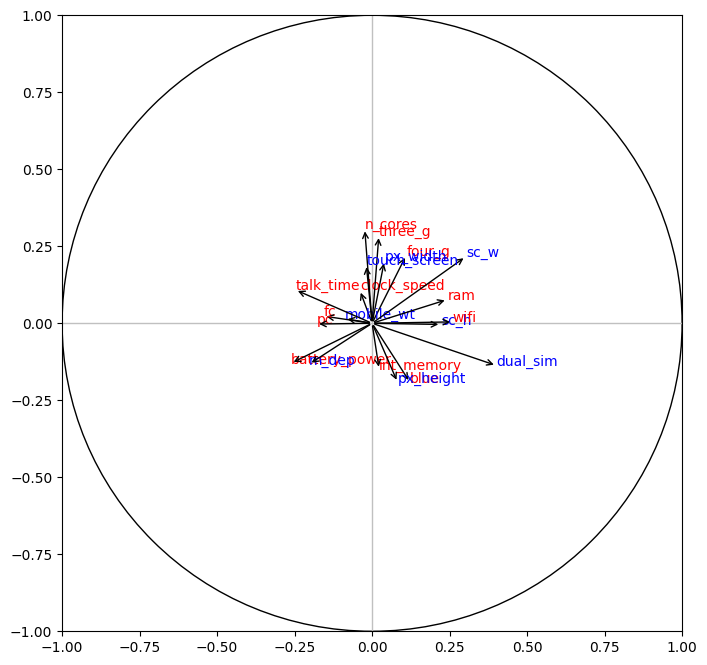

In [35]:
fig, axes = plt.subplots(figsize=(8,8))
axes.set_xlim(-1,1)
axes.set_ylim(-1,1)

# Print the labels (variable names)
for col in scaled_variables_df:
    if col in p_ext.columns: color="b"
    elif col in q_int.columns: color="r"
    else: color = "black"

    # Get coordinates in the two canonical components
    coord_horizontal = .5 * (corr_cc_var.at["p1",col] + corr_cc_var.at["q1",col])
    coord_vertical = .5 * (corr_cc_var.at["p2",col] + corr_cc_var.at["q2",col])
    plt.annotate(col,(coord_horizontal,coord_vertical), color=color)
    axes.annotate("", xy=(coord_horizontal,coord_vertical), xytext=(0, 0),arrowprops=dict(arrowstyle="->", color="black"))

# Add the axes
plt.plot([-1,1],[0,0],color='silver',linestyle='-',linewidth=1)
plt.plot([0,0],[-1,1],color='silver',linestyle='-',linewidth=1)

# Add a circle
cercle = plt.Circle((0,0),1,color='black',fill=False)
axes.add_artist(cercle)
# Print the correlation circle
plt.show()

##### Interpret the obtained results

**The angle of an arrow relative to the axes indicates the level of correlation it has with that component: variables aligned with an axis are strongly correlated with that component, while those at a 90 degrees angle to an axis are uncorrelated. The x axis represents the first component (p1 and q1) and the y axis the second (p2 and q2), so variables positioned more to the right have positve correlations with p1, while those to the left have negative correlations. The same applies to p2 with the upper and lower halves of the circle.**

**Moreover, like for the PCA correlatiob circle, variables closer to the edge of the circle are strongly correlated to the components, while those closer to the origin are weakly related. Variables pointing in similar directions are positively correlated with each other, while those pointing in opposite directions are negatively correlated, and closer to 90 degrees are approximately uncorrelated.**

**In our case, he variable furthest from the origin is `dual_sim` from group p. Its distance from the origin suggests it has the strongest (though still weak) correlation with the components, while its position indicates that this correlation is mostly with p1 (positively) and slightly with with p2 (negatively), since the arrow's angle is closer to the x axis than to the y axis.**

**Other variables show correlations that are weaker but clearer to one axis. For example, `wifi` is almost perfectly aligned with the x axis and is positioned to the right, meaning it contributes almost exclusively to the first component p1 and not the second p2, although this contribution is weaker overall than that of `dual_sim`.**

**However, most variables are still clustered closely around the origin, and even the ones furthest from it are not close enough to the edge of the circle to indicate a strong relationship. This means eaning that the first 2 components do not explain a significant amount of variance for the majority of the original variables, which aligns with our previous results where we found very low correlations between the 2 groups.**

#### Individual visualization

##### Show the individuals representation

[]

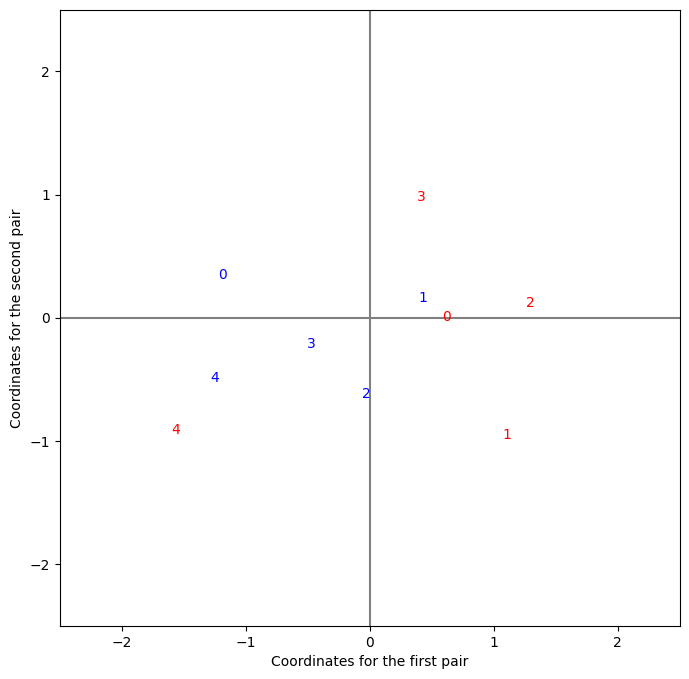

In [37]:
from matplotlib.pyplot import figure
fig, axes = plt.subplots(figsize=(8,8))

# We can plot the first 5 samples in the dataset
# by their coordinates in the first group of variables (in blue)
# and their coordinates in the second group of variables (in red)
# to see how far the two groups place the same sample.
for i in range(5):
    plt.annotate(i, (p_scores[i,0],p_scores[i,1]), color="b")
    plt.annotate(i, (q_scores[i, 0],q_scores[i, 1]), color="r")

plt.xlabel('Coordinates for the first pair')
plt.ylabel('Coordinates for the second pair')

# Modify xlim and ylim out zoom in and out of the figure
coord = 2.5
plt.xlim(-coord,coord)
plt.ylim(-coord,coord)

plt.hlines(0, -coord, coord, color="grey")
plt.vlines(0, -coord, coord, color="grey")

plt.plot()

##### Interpret the obtained results

**For the first 5 samples (0-4), each sample is represented twice: once with its coordinates generated for p, and once for those generated for q.**

**We can see that in our case, the representations for the same samples are quite spread out, with the exception of 4 which has its representations from p and q closer to each other, suggesting a better agreement between the 2 components in characterizing this sample.**

**However, the representations are overall still far from each other, confirming once again that the correlations between p and q are very low, and that the linear relationship of the 2 groups is weak.**

**While this is only a preview on the first 5 samples, these results, especially when paired with our previous observations, suggest that we would most likely not obtain better ones from the remaining samples.**

### CCA Conclusion
Based on your visualizations, do you think it would be useful to use the CCA results to reduce the dimensionality of your dataset before applying some form of clustering method, like you did with PCA? Why / why not?

**As we have seen from the correlation matrix, the correlation circle and the individuals representation, the 2 components derived from our 2 groups of variables p and q show very weak correlations, and thus do not form a strong enough basis for a lower-dimension representation that would preserve the structure relevant for clustering.**

**As such, reducing the dimensionality by dropping one of the 2 groups would most likely not help for clustering, because they each contribute unique information, and removing one would mean losing part of the overall data context, which could in fact make the clustering results even worse.**